In [1]:
import sys
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent directories to path
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'parameters'))
sys.path.insert(0, os.getcwd())

from analysis_utils import (
    load_best_runs,
    load_top_n_runs,
    extract_history,
    add_wall_times,
    plot_2d_histograms,
    plot_training_curves,
    plot_time_to_best,
    plot_speedrun_results,
    print_speedrun_table,
    print_best_hyperparameters,
    save_best_hyperparameters,
    get_optimizer_colors,
    ALL_OPTIMIZERS,
)

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

from analysis_utils import (
    plot_diagnostic_curves,
    plot_effective_lr_comparison,
    DIAG_KEYS_METRIC_SCALE,
    DIAG_KEYS_LEARNABLE,
    DIAG_KEYS_CURVATURE,
    DIAG_KEYS_TRAINING,
    DIAG_KEYS_OFFDIAG,
)


# Configuration


In [2]:
# Backend: "wandb" or "local"
BACKEND = "local"

# WandB settings (ignored if BACKEND == "local")
PROJECT = "induced_metric"
ENTITY = "thomas_harvey"

# Task settings
TASK_TAG = "cifar10_resnet18"
ITERATION = 0  # Iteration/batch number to load results from

# Optimizers to analyse
OPTIMIZERS = ['adam', 'adamw', 'sgd', 'sgd_metric', 'sgd_log_metric', 'muon', 'sgd_rms']
# OPTIMIZERS = ALL_OPTIMIZERS  # Uncomment to analyse all optimizers

# Results directory (for local backend)
RESULTS_DIR = os.path.join('..', '..', 'results')

# Metric configuration
SORT_METRIC = "final_max_val_acc"
SORT_ORDER = "-"
METRIC_KEY = "sweep_metric"
DIRECTION = "minimize"               # sweep_metric is -accuracy, so lower is better

# Speedrun targets (test accuracy thresholds)
SPEEDRUN_TARGETS = [0.60, 0.70, 0.75, 0.80, 0.82, 0.84, 0.86, 0.88]
SPEEDRUN_DIRECTION = "above"
SPEEDRUN_METRIC = "test_acc"

# History metrics to extract
HISTORY_METRICS = ["train_loss", "train_acc", "test_acc", "train_time_seconds"]

# 2D histogram axes
HIST_X = "final_max_acc_epoch"
HIST_Y = "final_max_val_acc"

# Time-to-best keys
BEST_EPOCH_KEY = "final_max_acc_epoch"
BEST_METRIC_KEY = "test_acc"

colors = get_optimizer_colors(OPTIMIZERS)
print(f"Backend: {BACKEND}")
print(f"Task: {TASK_TAG}, Iteration: {ITERATION}")
print(f"Optimizers: {OPTIMIZERS}")

Backend: local
Task: cifar10_resnet18, Iteration: 0
Optimizers: ['adam', 'adamw', 'sgd', 'sgd_metric', 'sgd_log_metric', 'muon', 'sgd_rms']


# Load Data


In [3]:
best_runs = load_best_runs(
    backend=BACKEND,
    optimizers=OPTIMIZERS,
    task_tag=TASK_TAG,
    project=PROJECT,
    entity=ENTITY,
    results_dir=RESULTS_DIR,
    metric_key=METRIC_KEY,
    direction=DIRECTION,
    sort_metric=SORT_METRIC,
    sort_order=SORT_ORDER,
    iteration=ITERATION,
)

top_n_runs = load_top_n_runs(
    backend=BACKEND,
    optimizers=OPTIMIZERS,
    n=50,
    task_tag=TASK_TAG,
    project=PROJECT,
    entity=ENTITY,
    results_dir=RESULTS_DIR,
    metric_key=METRIC_KEY,
    direction=DIRECTION,
    sort_metric=SORT_METRIC,
    sort_order=SORT_ORDER,
    iteration=ITERATION,
)

print(f"\nLoaded best runs for {len(best_runs)} optimizers")

Finding best run for adam...
  adam: No runs found
Finding best run for adamw...
  adamw: No runs found
Finding best run for sgd...
  sgd: No runs found
Finding best run for sgd_metric...
  sgd_metric: No runs found
Finding best run for sgd_log_metric...
  sgd_log_metric: No runs found
Finding best run for muon...
  muon: No runs found
Finding best run for sgd_rms...
  sgd_rms: No runs found
Loading top 50 runs for adam...
  adam: No runs found
Loading top 50 runs for adamw...
  adamw: No runs found
Loading top 50 runs for sgd...
  sgd: No runs found
Loading top 50 runs for sgd_metric...
  sgd_metric: No runs found
Loading top 50 runs for sgd_log_metric...
  sgd_log_metric: No runs found
Loading top 50 runs for muon...
  muon: No runs found
Loading top 50 runs for sgd_rms...
  sgd_rms: No runs found

Loaded best runs for 0 optimizers


# Distribution of Top Runs


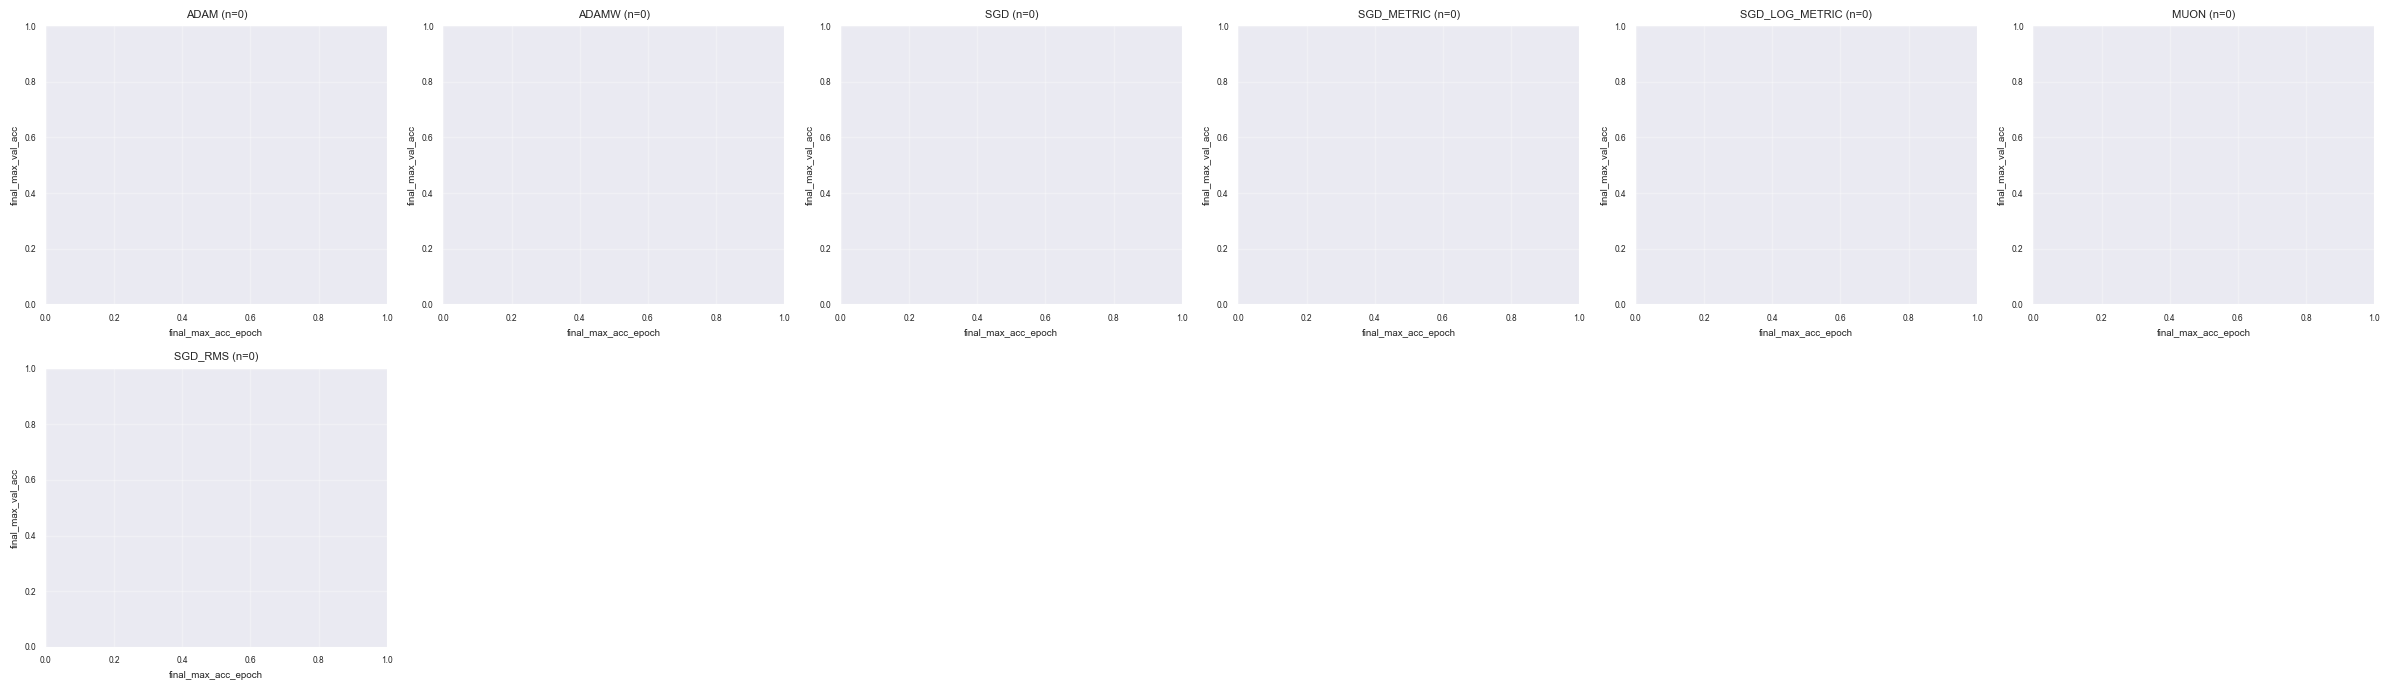

In [4]:
fig = plot_2d_histograms(
    top_n_runs, backend=BACKEND,
    x_metric=HIST_X, y_metric=HIST_Y,
    optimizers=OPTIMIZERS,
)
plt.show()


# Training History


In [5]:
optimizer_data = extract_history(BACKEND, best_runs, HISTORY_METRICS)
add_wall_times(optimizer_data)

print(f"Extracted history for {len(optimizer_data)} optimizers")


Extracted history for 0 optimizers


In [6]:
fig = plot_time_to_best(
    best_runs, optimizer_data,
    best_epoch_key=BEST_EPOCH_KEY,
    best_metric_key=BEST_METRIC_KEY,
    colors=colors,
)
plt.show()


Time to reach best metric for each optimizer:
  No data available.


<Figure size 800x550 with 0 Axes>

# Training Curves


/Users/noah-everett/Library/Mobile Documents/com~apple~CloudDocs/Projects/induced-metric-optimiser/repo/analysis/plots.py:222: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


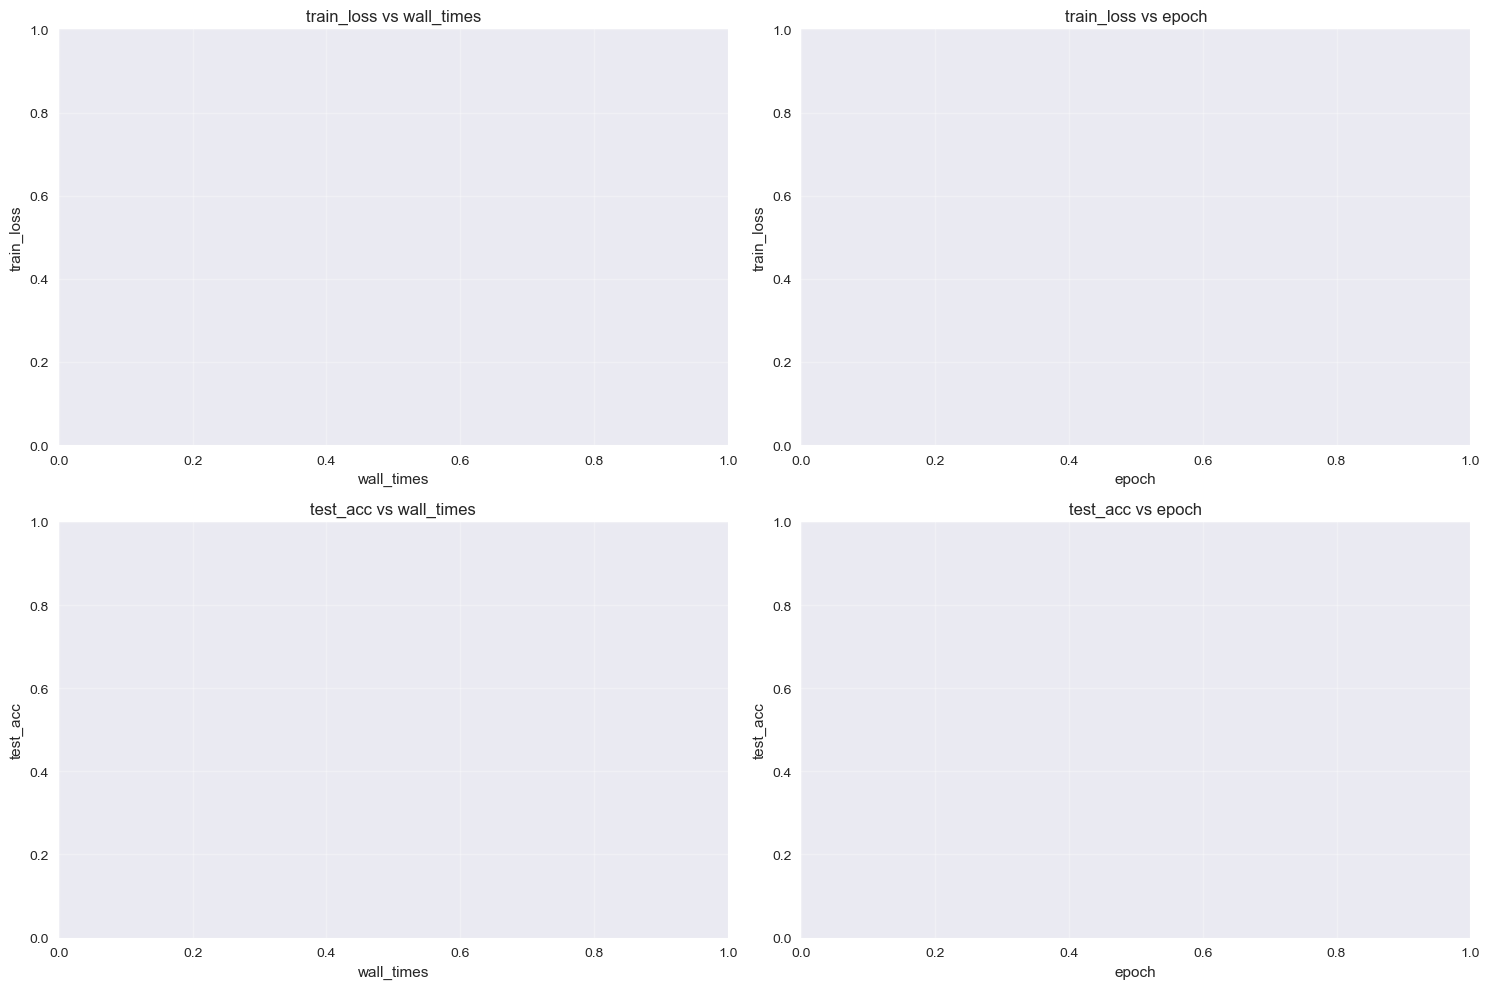

In [7]:
fig = plot_training_curves(
    optimizer_data,
    x_keys=["wall_times", "epoch"],
    y_keys=["train_loss", "test_acc"],
    colors=colors,
)
plt.show()


# Speedrun Analysis


Speedrun Results: Time (seconds) to reach target test accuracy
Optimizer                0.6       0.7       0.75      0.8       0.82      0.84      0.86      0.88      
---------------------------------------------------------------------------------------------------------


/Users/noah-everett/Library/Mobile Documents/com~apple~CloudDocs/Projects/induced-metric-optimiser/repo/analysis/plots.py:671: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)


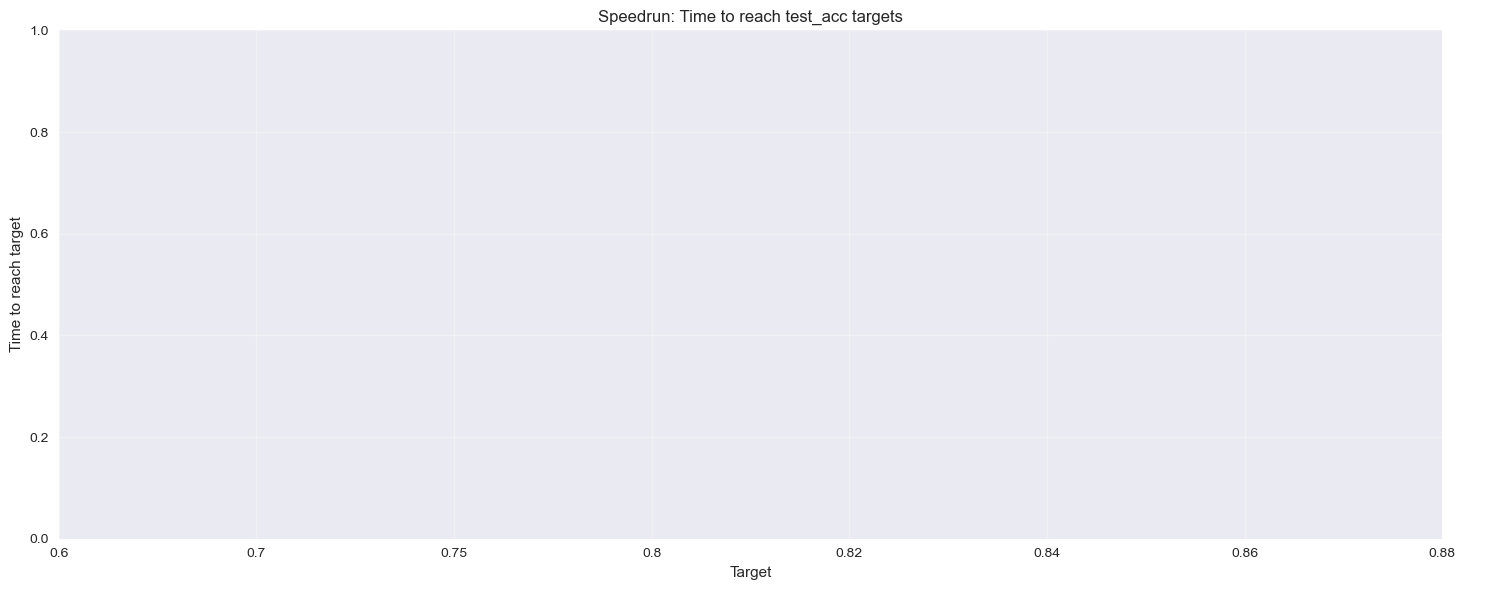

In [8]:
print("Speedrun Results: Time (seconds) to reach target test accuracy")
print("=" * 80)
print_speedrun_table(optimizer_data, SPEEDRUN_TARGETS, SPEEDRUN_METRIC, SPEEDRUN_DIRECTION)

fig = plot_speedrun_results(
    optimizer_data, SPEEDRUN_TARGETS,
    metric_key=SPEEDRUN_METRIC,
    direction=SPEEDRUN_DIRECTION,
    colors=colors,
)
plt.show()


# Best Hyperparameters


In [9]:
print_best_hyperparameters(best_runs)

filename = f'best_hyperparameters_CIFAR10_itr_{ITERATION}.csv'
df = save_best_hyperparameters(best_runs, filename)
df

Hyperparameters for Best Runs
Saved hyperparameters to best_hyperparameters_CIFAR10_itr_0.csv


""


# Optimizer Diagnostics

Internal state diagnostics (requires `--diagnostics` flag during sweep).
Skips gracefully if no diagnostic data is present.

In [10]:
# Extract diagnostic metrics from best runs
diag_keys = (
    DIAG_KEYS_METRIC_SCALE + DIAG_KEYS_LEARNABLE +
    DIAG_KEYS_CURVATURE + DIAG_KEYS_TRAINING + DIAG_KEYS_OFFDIAG
)
diag_data = extract_history(BACKEND, best_runs, diag_keys)


In [11]:
plot_diagnostic_curves(diag_data, DIAG_KEYS_TRAINING,
    title="Training-Level Diagnostics")
plt.show()


  [skip] No diagnostic data for: Training-Level Diagnostics


In [12]:
plot_diagnostic_curves(diag_data, DIAG_KEYS_METRIC_SCALE,
    title="Metric Scale (r, v_hat, metric_ema)")
plt.show()


  [skip] No diagnostic data for: Metric Scale (r, v_hat, metric_ema)


In [13]:
plot_diagnostic_curves(diag_data, DIAG_KEYS_LEARNABLE,
    title="Learnable Metric Diagnostics")
plt.show()


  [skip] No diagnostic data for: Learnable Metric Diagnostics


In [14]:
plot_effective_lr_comparison(diag_data)
plt.show()


  [skip] No diagnostic data for: Effective Learning Rate Comparison


In [15]:
plot_diagnostic_curves(diag_data, DIAG_KEYS_CURVATURE,
    title="Curvature-Aware Diagnostics")
plt.show()


  [skip] No diagnostic data for: Curvature-Aware Diagnostics


In [16]:
plot_diagnostic_curves(diag_data, DIAG_KEYS_OFFDIAG,
    title="Off-Diagonal (Woodbury) Diagnostics")
plt.show()


  [skip] No diagnostic data for: Off-Diagonal (Woodbury) Diagnostics
